---
#### **라이브러리 import 및 데이터 로드**
- Pandas, Numpy, Matplotlib import
- 수정주가, 시가총액, 섹터, 매출총이익, 총자산 데이터 불러오기

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

In [2]:
# GP 팩터용: 수정주가, 시가총액, 섹터, 매출총이익, 총자산 (경로: input/)
adj_close_df    = pd.read_csv("../input/KOSPI_KOSDAQ_adj_close.csv", index_col="Date", parse_dates=True)
mkt_cap_df      = pd.read_csv("../input/KOSPI_KOSDAQ_mkt_cap.csv", index_col="Date", parse_dates=True)
sector_df       = pd.read_csv("../input/KOSPI_KOSDAQ_sector.csv", index_col="Date", parse_dates=True)
gross_profit_df = pd.read_csv("../input/KOSPI_KOSDAQ_gross_profit.csv", index_col="Date", parse_dates=True)
total_assets_df = pd.read_csv("../input/KOSPI_KOSDAQ_total_asset.csv", index_col="Date", parse_dates=True)

---
#### **초기 작업 및 설정**
- 월 수익률 생성
- **연간 수익률** 리샘플링 (당해 4월 ~ 익년 3월, 12개월 복리)
- GP 팩터 생성 (매출총이익/총자산, 15기간 lag)
- 리밸런싱 기준일(3월 말), 포트폴리오 수익률 저장 객체

In [18]:
# 월 수익률
ret_m = adj_close_df.resample('ME').last().pct_change(fill_method=None)

In [43]:
# 백테스트 기간, 월말 리스트
start_date = '1999-12-31'
end_date   = '2025-12-31'
month_ends = pd.date_range(start=start_date, end=end_date, freq='ME').tolist()

# 연간 수익률: 구간 = 당해 4월 ~ 익년 3월 (12개월), 인덱스 = 구간 종료일(3월 말)
march_ends = [d for d in month_ends if d.month == 3]
ret_annual = pd.DataFrame(index=march_ends[1:], columns=ret_m.columns, dtype=float)
for i in range(1, len(march_ends)):
    period_end = march_ends[i]
    idx_end = month_ends.index(period_end)
    if idx_end < 11:
        continue
    months_12 = month_ends[idx_end - 11 : idx_end + 1]  # 12개월 (전년 4월 ~ 당해 3월)
    ret_annual.loc[period_end] = (1 + ret_m.loc[months_12]).prod() - 1

ret_annual

,삼성전자,SK하이닉스,현대차,LG에너지솔루션,한화에어로스페이스,삼성바이오로직스,SK스퀘어,기아,두산에너빌리티,HD현대중공업,...,웨이포트,성융광전투자,완리,골든센츄리,평산차업 KDR,네프로아이티,중국고섬,SBI모기지,SBI핀테크솔루션즈,SNK
2001-03-31,-0.379104,-0.871749,0.283582,0.000000,-0.542099,0.000000,0.000000,0.460000,0.131030,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2002-03-31,0.769231,-0.543573,1.436047,0.000000,0.669541,0.000000,0.000000,0.924658,1.400110,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2003-03-31,-0.228261,-0.906251,-0.427208,0.000000,-0.317840,0.000000,0.000000,-0.495374,-0.561454,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2004-03-31,1.014085,3.622642,1.183333,0.000000,1.069783,0.000000,0.000000,0.664316,0.470065,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2005-03-31,-0.122378,0.065306,0.049618,0.000000,-0.199984,0.000000,0.000000,0.186441,0.925129,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2006-03-31,0.254980,1.214559,0.485455,0.000000,1.916708,0.000000,0.000000,0.425000,1.268637,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2007-03-31,-0.106349,0.121107,-0.190942,0.000000,0.330210,0.000000,0.000000,-0.363409,0.894087,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2008-03-31,0.106572,-0.140432,0.193646,0.000000,0.506289,0.000000,0.000000,-0.102362,1.179254,0.000000,...,0.000000,0.000000,0.000000,0.000000,-0.518180,0.000000,0.000000,0.000000,0.000000,0.000000
2009-03-31,-0.088283,-0.556553,-0.296578,0.000000,-0.216929,0.000000,0.000000,-0.251754,-0.486791,0.000000,...,0.000000,0.000000,0.000000,0.000000,-0.317130,0.000000,0.000000,0.000000,0.000000,0.000000
2010-03-31,0.440141,1.161943,1.081081,0.000000,0.878331,0.000000,0.000000,1.960141,0.332353,0.000000,...,0.000000,0.000000,0.000000,0.000000,3.108475,-0.614081,0.000000,0.000000,0.000000,0.000000


---
#### **GP 팩터 데이터프레임 생성**
- GP = 매출총이익 / 총자산
- 매출총이익·총자산 각각 15기간 lag 적용
- index=월말, columns=종목, values=GP

In [44]:
# 월말로 리샘플
gp_m = gross_profit_df.resample('ME').last()
ta_m = total_assets_df.resample('ME').last()

# 15기간 lag
LAG = 15
gp_lag = gp_m.shift(LAG)
ta_lag = ta_m.shift(LAG).replace(0, np.nan)

# GP = 매출총이익 / 총자산 (0으로 나누기 방지)
gp_df = gp_lag / ta_lag
gp_df = gp_df.loc[gp_df.index[LAG]:]
gp_df

,삼성전자,SK하이닉스,현대차,LG에너지솔루션,한화에어로스페이스,삼성바이오로직스,SK스퀘어,기아,두산에너빌리티,HD현대중공업,...,웨이포트,성융광전투자,완리,골든센츄리,평산차업 KDR,네프로아이티,중국고섬,SBI모기지,SBI핀테크솔루션즈,SNK
Date,,,,,,,,,,,,,,,,,,,,,
1991-03-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1991-04-30,0.25819,0.081780,0.136760,NaN,0.157308,NaN,NaN,0.131733,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1991-05-31,0.25819,0.081780,0.136760,NaN,0.157308,NaN,NaN,0.131733,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1991-06-30,0.25819,0.081780,0.136760,NaN,0.157308,NaN,NaN,0.131733,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1991-07-31,0.25819,0.081780,0.136760,NaN,0.157308,NaN,NaN,0.131733,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-08-31,0.22216,0.265555,0.105207,0.056478,0.066222,0.098705,0.274319,0.267053,0.103733,0.077043,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.086783,NaN
2025-09-30,0.22216,0.265555,0.105207,0.056478,0.066222,0.098705,0.274319,0.267053,0.103733,0.077043,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.086783,NaN
2025-10-31,0.22216,0.265555,0.105207,0.056478,0.066222,0.098705,0.274319,0.267053,0.103733,0.077043,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.086783,NaN


---
#### **연간 리밸런싱 포트폴리오 수익률 (GP 상위 N종목)**
- **팩터 기준일**: 매년 3월 말 (GP 등 팩터 관측 시점)
- **매수 시점**: 4월 초부터 보유 시작 → 익년 3월 말까지 12개월 보유
- 코스피/코스닥 금융업 제외, GP 상위 N종목 동일가중

**로직 요약**
1. **준비**: 월말 섹터 정렬, 3월 말만 추출해 리밸런싱(팩터) 시점 리스트 생성
2. **종목 선정**: 각 3월 말 시점에서 금융업 제외 → GP 상위 N종목 선정
3. **보유 구간 수익률**: 연간 수익률 `ret_annual`(4월~익년 3월)에서 해당 구간 행을 사용해, 선정 종목의 동일가중 평균 연수익률 계산
4. **저장**: 구간 수익률을 구간 종료일(익년 3월 말) 인덱스로 `portfolio_returns`에 저장

In [49]:
# ----- 1) 섹터 데이터를 월말 일자에 맞춰 정렬 (결측은 직전 값으로 ffill) -----
month_ends_dt = pd.DatetimeIndex(month_ends)
sector_m = sector_df.reindex(month_ends_dt).ffill()

FINANCIAL_PATTERN = '금융|증권|보험'
N_TOP = 20

# ----- 2) 리밸런싱: 3월 말 팩터 기준 → 4월 초부터 매수, 보유 구간 = 당해 4월 ~ 익년 3월 -----
# march_ends: 팩터 관측일(3월 말). portfolio_returns 인덱스 = 구간 종료일(익년 3월 말)
portfolio_returns = pd.Series(index=march_ends[1:], dtype=float)

for i in range(len(march_ends) - 1):
    factor_date = march_ends[i]    # 팩터 기준일 (이번 3월 말) → 이 시점 GP로 종목 선정
    period_end  = march_ends[i + 1]  # 보유 구간 종료일 (다음 해 3월 말) → 4월~익년 3월 수익 반영

    if factor_date not in gp_df.index or period_end not in ret_annual.index:
        continue

    # 해당 시점 섹터에서 금융업 제외한 종목 리스트
    sector_row = sector_m.loc[factor_date]
    is_financial = sector_row.astype(str).str.contains(FINANCIAL_PATTERN, na=False)
    non_financial_tickers = sector_row[~is_financial].dropna().index.tolist()

    # 금융 제외 종목 중 GP 상위 N_TOP 선정
    gp_t = gp_df.loc[factor_date, gp_df.columns.intersection(non_financial_tickers)].dropna()
    if gp_t.empty or len(gp_t) < N_TOP:
        continue
    selected = gp_t.nlargest(N_TOP).index.tolist()

    # 연간 수익률(4월~익년 3월)에서 해당 구간 행 사용, 선정 종목 동일가중 평균
    common = ret_annual.loc[period_end, ret_annual.columns.intersection(selected)].dropna()
    if common.empty:
        continue
    # 동일가중: (1+r) 평균 - 1
    portfolio_returns.loc[period_end] = (1 + common).mean() - 1

portfolio_returns

2001-03-31    0.021632
2002-03-31    1.108301
2003-03-31   -0.608681
2004-03-31    0.360552
2005-03-31    0.256822
2006-03-31    0.887618
2007-03-31    0.072026
2008-03-31   -0.083994
2009-03-31   -0.144736
2010-03-31    0.516019
2011-03-31    0.300469
2012-03-31    0.248847
2013-03-31    0.131823
2014-03-31   -0.000188
2015-03-31    0.685092
2016-03-31    0.143689
2017-03-31   -0.126781
2018-03-31    0.307994
2019-03-31   -0.081793
2020-03-31   -0.247610
2021-03-31    1.015255
2022-03-31    0.142657
2023-03-31   -0.173200
2024-03-31   -0.185839
2025-03-31   -0.270964
dtype: float64

In [50]:
# 포트폴리오 NAV
nav = (1 + portfolio_returns.fillna(0)).cumprod()
nav

2001-03-31     1.021632
2002-03-31     2.153907
2003-03-31     0.842865
2004-03-31     1.146761
2005-03-31     1.441275
2006-03-31     2.720576
2007-03-31     2.916529
2008-03-31     2.671559
2009-03-31     2.284890
2010-03-31     3.463936
2011-03-31     4.504741
2012-03-31     5.625734
2013-03-31     6.367335
2014-03-31     6.366137
2015-03-31    10.727527
2016-03-31    12.268955
2017-03-31    10.713482
2018-03-31    14.013169
2019-03-31    12.866995
2020-03-31     9.680993
2021-03-31    19.509675
2022-03-31    22.292860
2023-03-31    18.431737
2024-03-31    15.006395
2025-03-31    10.940202
dtype: float64

<Axes: title={'center': 'GP 상위 N종목 연간 리밸런싱 NAV (3월 말 팩터, 4월~익년 3월 보유)'}>

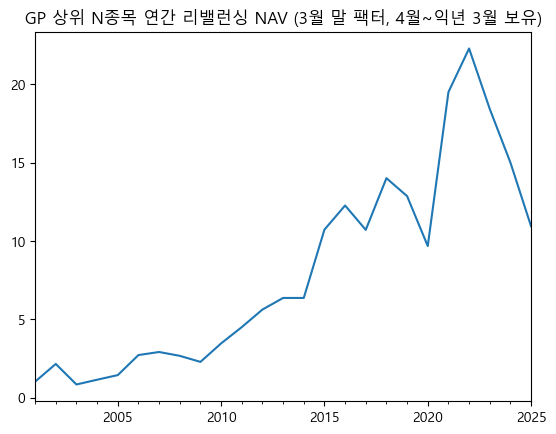

In [51]:
nav.plot(title='GP 상위 N종목 연간 리밸런싱 NAV (3월 말 팩터, 4월~익년 3월 보유)')

In [52]:
# 성과 지표
rf_annual = 0.02
returns = portfolio_returns.dropna()
start_val = 1.0
end_val = nav.iloc[-1] / nav.iloc[0]
years = (nav.index[-1] - nav.index[0]).days / 365.25
cagr = (end_val ** (1 / years)) - 1 if years > 0 else 0
volatility = returns.std()
excess_return = returns.mean() - rf_annual
sharpe_ratio = (excess_return / volatility) if volatility > 0 else np.nan
print(f"CAGR: {cagr:.2%}")
print(f"Annualized Volatility: {volatility:.2%}")
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")

CAGR: 10.38%
Annualized Volatility: 41.73%
Sharpe Ratio: 0.36
